# Housing Price Analysis

A demo notebook for Notebook Headings: open it and look at the headings view.

## Setup

### Imports

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

### Load data

In [ ]:
df = pd.read_csv('housing.csv')
df.head(10)

,area,rooms,year,district,price
0,1500.0,5,1980,East,434400.0
1,1619.0,5,1993,North,478200.0
2,1390.0,4,2004,West,403000.0
3,1144.0,1,1970,North,206000.0
4,1318.0,2,1978,South,314700.0
5,1103.0,5,1952,South,291000.0
6,1524.0,4,1969,East,357800.0
7,2036.0,5,1974,North,530600.0
8,1303.0,3,2009,West,339300.0
9,1252.0,3,2005,North,302400.0


## Data cleaning

### Missing values

In [ ]:
df.isna().sum()

,missing
area,12
rooms,0
year,0
district,0
price,0


In [ ]:
df = df.dropna(subset=['area'])

### Outliers

In [ ]:
df.describe()

,area,rooms,year,price
count,488.0,500.0,500.0,500.0
mean,1451.8,3.4,1987.4,368802.2
std,372.9,1.7,21.5,92285.6
min,400.0,1.0,1950.0,104600.0
25%,1186.8,2.0,1969.0,310850.0
50%,1465.0,3.0,1987.0,375000.0
75%,1704.5,5.0,2005.0,425750.0
max,2515.0,6.0,2023.0,650700.0


## Exploration

### Price distribution

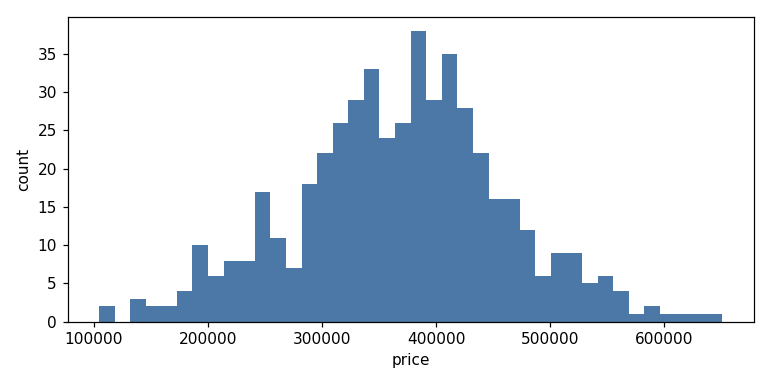

In [ ]:
df.price.plot.hist(bins=40)

### Correlations ???

In [ ]:
df.select_dtypes('number').corr()

,area,rooms,year,price
area,1.00,-0.01,-0.02,0.84
rooms,-0.01,1.00,0.05,0.19
year,-0.02,0.05,1.00,0.19
price,0.84,0.19,0.19,1.00


#### By district

In [ ]:
df.groupby('district').price.describe()

,count,mean,std,min,25%,50%,75%,max
district,,,,,,,,
East,120.0,358500.0,92032.0,104600.0,303700.0,347950.0,419650.0,608800.0
North,110.0,369563.0,92122.0,188700.0,304850.0,374150.0,415800.0,650700.0
South,126.0,379078.0,98425.0,144100.0,321450.0,388850.0,448000.0,560100.0
West,144.0,367815.0,86892.0,157500.0,321975.0,376300.0,414150.0,610400.0


#### By year built

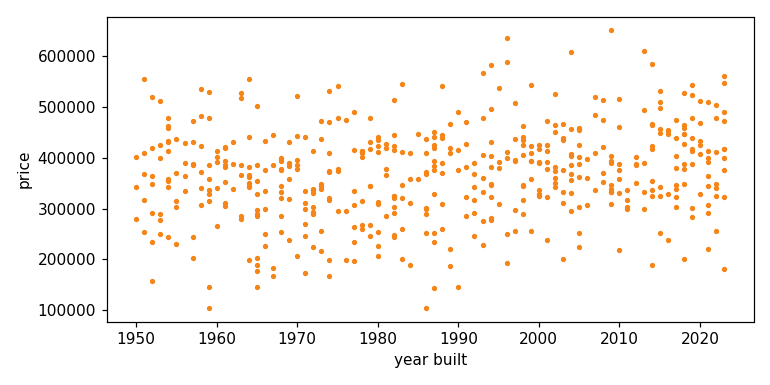

In [ ]:
df.plot.scatter('year', 'price', s=6)

## Modeling

### Baseline model

In [ ]:
from sklearn.linear_model import LinearRegression
base = LinearRegression().fit(X_train, y_train)
base.score(X_test, y_test)

R² = 0.71


### Gradient boosting

#### Hyperparameter search

In [ ]:
search = GridSearchCV(GradientBoostingRegressor(), grid, cv=5, verbose=2)
search.fit(X_train, y_train)

[000] depth=2 lr=0.02 n=400  cv R²=0.787
[001] depth=2 lr=0.03 n=400  cv R²=0.766
[002] depth=2 lr=0.04 n=400  cv R²=0.723
[003] depth=2 lr=0.05 n=400  cv R²=0.757
[004] depth=2 lr=0.06 n=400  cv R²=0.731
[005] depth=2 lr=0.07 n=400  cv R²=0.792
[006] depth=2 lr=0.08 n=400  cv R²=0.734
[007] depth=2 lr=0.09 n=400  cv R²=0.720
[008] depth=2 lr=0.10 n=400  cv R²=0.704
[009] depth=2 lr=0.11 n=400  cv R²=0.734
[010] depth=2 lr=0.12 n=400  cv R²=0.799
[011] depth=2 lr=0.13 n=400  cv R²=0.722
[012] depth=2 lr=0.14 n=400  cv R²=0.746
[013] depth=2 lr=0.15 n=400  cv R²=0.797
[014] depth=2 lr=0.16 n=400  cv R²=0.701
[015] depth=2 lr=0.16 n=400  cv R²=0.730
[016] depth=2 lr=0.17 n=400  cv R²=0.782
[017] depth=2 lr=0.18 n=400  cv R²=0.710
[018] depth=2 lr=0.19 n=400  cv R²=0.793
[019] depth=2 lr=0.20 n=400  cv R²=0.783
[020] depth=2 lr=0.21 n=400  cv R²=0.714
[021] depth=2 lr=0.22 n=400  cv R²=0.759
[022] depth=2 lr=0.23 n=400  cv R²=0.756
[023] depth=2 lr=0.24 n=400  cv R²=0.769
[024] depth=2 lr

#### Feature importance

In [ ]:
pd.Series(model.feature_importances_, X.columns).sort_values()

## Results

### Summary table

In [ ]:
results

,model,R²,MAE
0,Linear,0.71,38200
1,Boosting,0.83,27400


### Next steps